In [3]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import math
from datetime import datetime
from PIL import Image
from skimage import color
from skimage import io
import cv2

# Load data

In [3]:
ls 20220730/pass_281_182532_ffc/

frame_c307_20220730_182502_sky_bluesky.png
frame_c307_20220730_182503_sky_bluesky.png
frame_c307_20220730_182504_sky_bluesky.png
frame_c307_20220730_182505_sky_bluesky.png
frame_c307_20220730_182506_sky_bluesky.png
frame_c307_20220730_182507_sky_bluesky.png
frame_c307_20220730_182508_sky_bluesky.png
frame_c307_20220730_182509_sky_bluesky.png
frame_c307_20220730_182510_sky_bluesky.png
frame_c307_20220730_182511_sky_bluesky.png
frame_c307_20220730_182512_sky_bluesky.png
frame_c307_20220730_182513_sky.png
frame_c307_20220730_182514_sky.png
frame_c307_20220730_182515_sky_bluesky.png
frame_c307_20220730_182516_sky_bluesky.png
frame_c307_20220730_182517_sky_bluesky.png
frame_c307_20220730_182518_sky_bluesky.png
frame_c307_20220730_182519_sky_bluesky.png
frame_c307_20220730_182520_sky_bluesky.png
frame_c307_20220730_182521_sky_bluesky.png
frame_c307_20220730_182522_sky_bluesky.png
frame_c307_20220730_182523_sky_bluesky.png
frame_c307_20220730_182524_sky_bluesky.png
frame_c307_20220730_182525_

In [4]:
frame='frame_c307_20220730_182529_sky_bluesky.png'
file_name = '20220730/pass_281_182532_ffc/'+frame
dataset = xr.open_dataset('core_faam_20220730_v005_r0_c307_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')
ffc=True
rfc=False

# Functions to extract air craft data, cloud position and distance camera to cloud

In [5]:
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    pass_number= filepath_parts[1].split('_')[1]
    return pass_number

In [6]:
def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

In [7]:
# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

In [8]:
def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['PALT_RVS'].data[:]
    veln = dataset['VELN_GIN'].data[:]
    vele = dataset['VELE_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 'roll_angles': roll_angle, 'veln': veln, 'vele': vele})
    return aircraft_df


In [9]:
def extract_cloud_pass_info(cloud_passes, pass_number):
    pass_info = cloud_passes.loc[int(pass_number)-1]
    cloud_lat1 = pass_info['start_lat']
    cloud_lon1 = pass_info['start_lon']
    cloud_lat2 = pass_info['end_lat']
    cloud_lon2 = pass_info['end_lon']
    start_time = datetime.strptime(pass_info['start_datetime'], '%Y-%m-%d %H:%M:%S')
    end_time = datetime.strptime(pass_info['end_datetime'], '%Y-%m-%d %H:%M:%S')
    return [cloud_lat1, cloud_lon1, cloud_lat2, cloud_lon2, start_time, end_time]

In [10]:
def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

In [11]:
# Get the distance
#extract info
camera, timestamp = extract_timestamp_from_filename(file_name)
pass_number = extract_pass_number(file_name)
aircraft_df = extract_variables(dataset)
aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
pass_info = extract_cloud_pass_info(cloud_passes, pass_number)
pass_lat1, pass_lon1, pass_lat2, pass_lon2, start_time, end_time = pass_info
# get mid pass time and thus the aircraft position at that time
mid_pass_time = start_time + (end_time - start_time)/2
aircraft_pass_position = get_closest_roll_angle(aircraft_df, mid_pass_time)

# Check roll
if abs(aircraft_position['roll_angles']) > 10:
    print('Aircraft is not level')
elif abs(aircraft_pass_position['roll_angles']) > 10:
    print('Aircraft is not level')
        



In [12]:
D1 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon1, pass_lat1, aircraft_pass_position['alt'])
D2 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon2, pass_lat2, aircraft_pass_position['alt'])
D = (D1 + D2)/2

In [13]:
print('Distance to cloud start: ', D1, 'm')
print('Distance to cloud end: ', D2, 'm')
print('Distance to cloud mid: ', D, 'm')

Distance to cloud start:  380.4850460452328 m
Distance to cloud end:  1145.3258460919958 m
Distance to cloud mid:  762.9054460686143 m


In [14]:
print('Using Distance to cloud mid: ', + D)
distance_override=False
pass_portion = 0.8
if distance_override:
    D = (D1 + D2) * pass_portion
    print('Overriding distance to: ', D)

Using Distance to cloud mid:  762.9054460686143


In [15]:
aircraft_pass_position

times          2022-07-30 18:25:35
lat                      34.212845
lon                     -107.20536
pitch                     9.638947
alt                    3061.373047
roll_angles              -0.012393
veln                     85.845108
vele                     94.019981
Name: 18064, dtype: object

# find pixel height

In [16]:
# Set Constants for edge detection:
# How white vs grey (this might need to be set by trial and error)    
WHITENESS_THRESHOLD = 150
# line thickness of box
THICKNESS = 10
# The part of every photo is just ground set to 0 if whole photo is cloud
NOTSKY = 325

NameError: name 'cv' is not defined

In [17]:


img = io.imread(file_name)
img_grey = color.rgb2gray(img)

In [18]:
img_grey = cv2.bilateralFilter(img, 18, 100, 100)
mask = np.all(img > WHITENESS_THRESHOLD, axis=-1)
img_grey[~mask] = 0
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (7, 7), 0)
edges = cv2.Canny(cv_grey, 0, 200)
edges[NOTSKY::,:]=0
edges[:,0:20]=0
edges[:,-15::]=0

# Find contours and sort by area
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

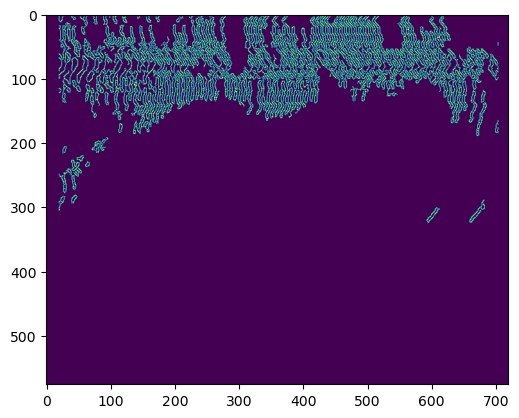

In [19]:
plt.imshow(edges)

In [20]:
# Draw the contours on the original image
thickness = 8  # Adjust this value to control the thickness of the drawn contours
edge_image = cv2.imread(file_name).copy()
cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)

array([[[36, 33, 40],
        [44, 41, 48],
        [18, 31, 34],
        ...,
        [21, 17, 20],
        [19, 32, 35],
        [32, 45, 48]],

       [[31, 28, 35],
        [30, 27, 34],
        [11, 24, 27],
        ...,
        [21, 17, 20],
        [10, 23, 26],
        [23, 36, 39]],

       [[46, 28, 33],
        [37, 19, 24],
        [19, 17, 22],
        ...,
        [32, 31, 33],
        [ 5, 20, 23],
        [11, 26, 29]],

       ...,

       [[ 8, 20, 17],
        [ 8, 20, 17],
        [ 0, 23, 17],
        ...,
        [ 0, 21, 19],
        [ 0, 23, 26],
        [ 0, 20, 23]],

       [[ 0, 23, 17],
        [ 0, 23, 17],
        [ 0, 26, 17],
        ...,
        [ 0, 32, 33],
        [ 0, 26, 32],
        [ 0, 19, 25]],

       [[ 0, 23, 17],
        [ 0, 23, 17],
        [ 0, 25, 16],
        ...,
        [ 0, 29, 30],
        [ 0, 23, 29],
        [ 0, 19, 25]]], dtype=uint8)

In [21]:
cv2.imwrite('cloud_edge.png', edge_image)
cloud_edge=Image.open('cloud_edge.png')

photo is 720 pixels wide plane nose looks off center could use 360 otr 380 in line with nose?

In [22]:
x_target = 380
found_points = []

for contour in contours:
    for point in contour:
        # point is a 3D array: [[x, y]]
        x, y = point[0]
        if x == x_target:
            found_points.append((x, y))

if found_points:
    # If there are multiple points, you can decide how to handle them
    # Here, we'll just pick the first one for simplicity
    x, y = found_points[0]
    print(f"Contour intersects x={x_target} at y={y}")
else:
    print(f"No contours intersect x={x_target} trying to x={x_target+1}")
    x_target = 351
    found_points = []

    for contour in contours:
        for point in contour:
            # point is a 3D array: [[x, y]]
            x, y = point[0]
            if x == x_target:
                found_points.append((x, y))

    if found_points:
        # If there are multiple points, you can decide how to handle them
        # Here, we'll just pick the first one for simplicity
        x, y = found_points[0]
        print(f"Contour intersects x={x_target} at y={y}")
    else:
        print(f"No contours intersect x={x_target+1}")

Contour intersects x=380 at y=153


In [23]:
pixel_height = 576- y


In [24]:
pixel_height_override = False
yo = 150
if pixel_height_override:
    pixel_height = 576-yo
    print('Overriding pixel height to: ', pixel_height)

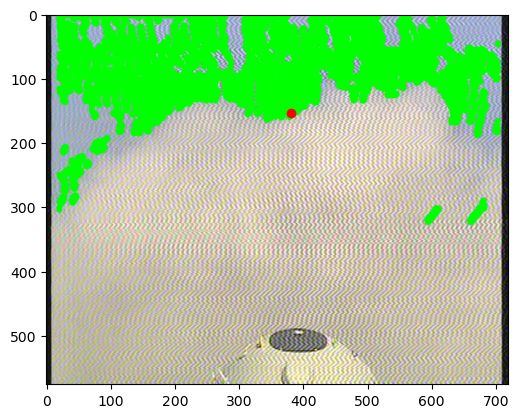

In [25]:
plt.imshow(cloud_edge)
plt.plot(x_target, 576-pixel_height, 'ro')

# find cloud height

[LTC3244/20](https://www.sourcesecurity.com/datasheets/bosch-ltc-3214-20/co-289-ga/FixedLenses.pdf)



In [78]:
focal_length_mm = 12        # Focal Length in mm
fov_vertical_deg = 23      # Field of View in degrees
fov_horizontal_deg = 30    # Field of View in degrees
FOV = 0         # Field of View (to be calculated later)


In [97]:
# Calculating FOV angles in degrees
# Convert FOV angles to radians
fov_horizontal_rad = math.radians(fov_horizontal_deg)
fov_vertical_rad = math.radians(fov_vertical_deg)
FOV = fov_vertical_deg

# Calculate sesnor height and width in mm from FOV angles
sensor_width_mm = 2 * focal_length_mm * math.tan(fov_horizontal_rad / 2)
sensor_height_mm = 2 * focal_length_mm * math.tan(fov_vertical_rad / 2)



# Displaying FOV angles
print("FOV Horizontal Angle:", fov_horizontal_deg, "degrees")
print("FOV Vertical Angle:", fov_vertical_deg, "degrees")

def calculate_sensor_dimensions(total_pixels, sensor_height_mm,sensor_width_mm):
    # Calculate the height in pixels
    aspect_ratio = sensor_width_mm / sensor_height_mm
    height_pixels = math.sqrt(total_pixels / aspect_ratio)
    
    # Calculate the width in pixels
    width_pixels = aspect_ratio * height_pixels
    
    return width_pixels, height_pixels

# Total number of pixels for a 3MP camera
total_pixels = 976 * 576

# Calculate sensor dimensions in pixels
#sensor_width_pixels, sensor_height_pixels = calculate_sensor_dimensions(total_pixels, sensor_height_mm, sensor_width_mm)
sensor_height_pixels=576
print(f"Sensor width in pixels: {sensor_width_pixels}")
print(f"Sensor height in pixels: {sensor_height_pixels}")
print(f"Sensor width in mm: {sensor_width_mm}")
print(f"Sensor height in mm: {sensor_height_mm}")
print(f"Sensor aspect ratio: {sensor_width_mm/sensor_height_mm}")
print(f"Sensor aspect ratio: {960/576}")

FOV Horizontal Angle: 30 degrees
FOV Vertical Angle: 23 degrees
Sensor width in pixels: 860.4607712684272
Sensor height in pixels: 576
Sensor width in mm: 6.430780618346945
Sensor height in mm: 4.8828551861687846
Sensor aspect ratio: 1.3170123571476842
Sensor aspect ratio: 1.6666666666666667


In [98]:
# Function to find height of an object given its pixel position on the sensor
# 960 H 
# 960 x 576 resolution image gives aspect ratio of 1.67 but FOV give aspect ratio of 1.3
def find_height(P, Distance, focal_length_mm, sensor_height_mm, sensor_height_pixels):
    """
    Calculate the height of an object given its pixel position on the sensor.

    Parameters:
    - P: Pixel position of the object on the photo
    - Distance: Distance to the object in km
    - focal_length_mm: Focal length of the camera lens in millimeters
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Height of the object in kilometers (rounded to 2 decimal places)
    """
    OHS = find_OHS(P, sensor_height_mm, sensor_height_pixels)
    H = (Distance * 10**3 * OHS) / focal_length_mm
    return round(H / 10**3, 2)

# Object height on sensor =  (Sensor height (mm) × Object height (pixels))
#                                      / Sensor height (pixels)


# Function to calculate Object Height on Sensor
def find_OHS(P, sensor_height_mm, sensor_height_pixels=576):
    """
    Calculate the Object Height on Sensor.

    Parameters:
    - P: Pixel position of the object on the photo
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Object Height on Sensor
    """
    # this value is a typical value for a 1/3" CCD sensor
    OHS = sensor_height_mm * P / sensor_height_pixels
    return OHS



def pitch_correct(P, FieldOfView, h):
    """
    Correct the pitch of the camera based on angles and height.

    Parameters:
    - P: pitch in degrees
    - FieldOfView: Field of View of the camera in degrees
    - h: Height on the inclined plane

    Returns:
    - True height after pitch correction
    """
    # See diagram for agles a, b and c
    a = 90 - P - FieldOfView/2
    b = 180 - 90 - FieldOfView/2
    # image plane incline from vertical
    c = 180 - a - b
    # x is true height, h is height on inclined place
    x = h * math.cos(math.radians(c))
    return x

In [99]:
CTH_raw= find_height(pixel_height, D, focal_length_mm, sensor_height_mm, sensor_height_pixels)
if rfc:
    CTH_rel_to_plane = pitch_correct(aircraft_position['pitch']-3, FOV, CTH_raw)
elif ffc:
    CTH_rel_to_plane = pitch_correct(aircraft_position['pitch']+3, FOV, CTH_raw)


In [100]:
cloud_top_height = CTH_rel_to_plane + aircraft_position['alt']

In [101]:
print('the estimated cloud top height is: ', cloud_top_height)

the estimated cloud top height is:  3194.4487408439504


In [102]:
print('the pass height was: ', aircraft_pass_position['alt'])

the pass height was:  3061.373


In [103]:
CTH_rel_to_plane 

185.13941467207547

In [104]:
cloud_top_height- aircraft_pass_position['alt']

133.07569396895042

In [105]:
CTH_raw

227.97